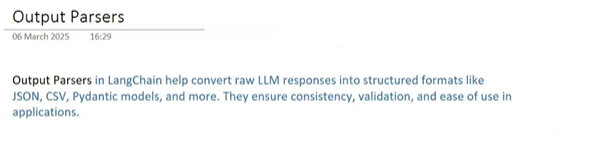

Types of Output Parser:
- Str Output Parser
- Json Output Parser
- Structured Output Parser
- Pydantic Output Parser


In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

model = HuggingFaceEndpoint(
    repo_id="microsoft/Phi-3-mini-4k-instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)

chat = ChatHuggingFace(llm=model, verbose=True)


## Mostly some model doesn't support structured output  
## So we can't use with_structured_output method instead we need to use output parser

json_schema = {
    "title": "Review",
    "type": "object",
    "properties": {
        "summary": {
            "type": "string",
            "description": "A summary of the review"
        },
        "stars": {
            "type": "integer",
            "description": "Star rating from 1 to 5"
        },
        "sentiment": {
            "type": "string",
            "enum": ["positive", "negative", "neutral"],
            "description": "Overall sentiment"
        },
        "pros": {
            "type": "string",
            "description": "Comma-separated list of pros"
        },
        "cons": {
            "type": "string",
            "description": "Comma-separated list of cons"
        }
    },
    "required": ["summary", "sentiment"]
}


structured_model = chat.with_structured_output(json_schema)

result = structured_model.invoke("""The hardware is great, but the software feels bloated.
There are too many pre-installed apps that I can't remove. Also, the UI looks outdated
compared to other brands. Hoping for a software update to fix this.""")

print(type(result))
print(result)

## Mostly some model doesn't support structured output  
## So we can't use with_structured_output method instead we need to use output parser

StopIteration: 

## Str Output Parser

In [18]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.chat_models import init_chat_model

llm = HuggingFaceEndpoint(
    repo_id="microsoft/Phi-3-mini-4k-instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)

model = ChatHuggingFace(llm=llm, verbose=True)

model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.7,
    max_tokens=1000,
    max_retries=2,
)

#Prompt 1 
template1 = PromptTemplate(
    input_variables=["topic"],
    template="Write the detailed report on {topic}"
)
#prompt 2
template2 = PromptTemplate(
    input_variables=["report"],
    template="Write the 5 line summary on the report {report}"
)


parser = StrOutputParser()

#Chain
chain = template1 | model | parser | template2 | model | parser

result = chain.invoke({"topic": "Black Hole"})

print("\nResult\n",result)

print("*"*50)
# prompt1 = template1.invoke({"topic": "Black Hole"})

# print("\nPrompt 1\n",prompt1.text)
# result = model.invoke(prompt1)

# print("\nResult\n",result.content)

# prompt2 = template2.invoke({"report": prompt1.text})

# print("\nPrompt 2\n",prompt2.text)


Result
 Here is a 5-line summary of the report **Detailed Report on Black Holes**:

Black holes are regions of spacetime with such strong gravitational pull that nothing can escape, formed when massive stars collapse in on themselves. They have unique properties, including event horizons and singularities, and are classified into four types: stellar, intermediate-mass, supermassive, and primordial. Observational evidence for black holes includes X-rays, gamma rays, radio waves, and gravitational waves, which have been detected by telescopes and collaborations. Recent discoveries, such as the detection of gravitational waves and a black hole merger, have provided insights into black hole properties and behavior. Further research and observations will continue to shed light on the mysteries of black holes.
**************************************************


## Json Output Parser

In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain.chat_models import init_chat_model

llm = HuggingFaceEndpoint(
    repo_id="microsoft/Phi-3-mini-4k-instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)

model = ChatHuggingFace(llm=llm, verbose=True)

model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.7,
    max_tokens=1000,
    max_retries=2,
)


parser = JsonOutputParser()
#Prompt 1 
template1 = PromptTemplate(
    input_variables=[],
    partial_variables={"formated_output":parser.get_format_instructions()},
    template="Give me the name , age and citye of the fictional person {formated_output}"
)

prompt = template1.format()

print("*"*150)
print(prompt)
print("*"*150)

result = model.invoke(prompt)
final_result = parser.parse(result.content)
print("\nbefore parsing\n",result.content)
print("\nfinal_result\n",final_result)



print("*"*150)
chain = template1 | model | parser
result = chain.invoke({})
print(result)


******************************************************************************************************************************************************
Give me the name , age and citye of the fictional person Return a JSON object.
******************************************************************************************************************************************************

before parsing
 Since I don't have any information about a specific fictional person, I will create a random example.

Here's a JSON object representing a fictional person:

```json
{
  "name": "Eryndor Thorne",
  "age": 32,
  "city": "Ashwood"
}
```

Let me know if you need any further assistance.

final_result
 {'name': 'Eryndor Thorne', 'age': 32, 'city': 'Ashwood'}
******************************************************************************************************************************************************
{'name': 'John Doe', 'age': 30, 'city': 'New York'}


# Pydantic Output Parser

In [3]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field

model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.3
)

class Person(BaseModel):
    name: str = Field(description="Name of the person")
    age: int = Field(gt=18,description="Age of the person")
    gender: str = Field(description="Gender of the person")
    
parser = PydanticOutputParser(pydantic_object=Person)

template = PromptTemplate(
    template="generate a name age and gender of a fictional character from {place} {format_instructions}",
    partial_variables={"format_instructions": parser.get_format_instructions()},
    input_variables=["place"]
)


print("*"*150)
prompt = template.invoke({"place": "India"})
print("prompt\n",prompt)
print("*"*150)

result = model.invoke(prompt)
final_result = parser.parse(result.content)
print(final_result)


print("*"*150)
chain = template | model | parser
result = chain.invoke({"place": "India"})
print(result)


******************************************************************************************************************************************************
prompt
 text='generate a name age and gender of a fictional character from India The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"name": {"description": "Name of the person", "title": "Name", "type": "string"}, "age": {"description": "Age of the person", "exclusiveMinimum": 18, "title": "Age", "type": "integer"}, "gender": {"description": "Gender of the person", "title": "Gender", "type": "string"}}, "required": ["name"

# Structured Output Parser

In [28]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StructuredOutputParser, ResponseSchema
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.7,
    max_tokens=1000,
    max_retries=2,
)

schema = [
    ResponseSchema(name="fact_1", description="Fact one about the topic"),
    ResponseSchema(name="fact_2", description="Fact two about the topic"),
    ResponseSchema(name="fact_3", description="Fact three about the topic"),
]

parser = StructuredOutputParser.from_response_schemas(schema)

template = PromptTemplate(
    input_variables=["topic"],
    template="Give me three facts about {topic}. {format_instructions}",
    output_parser=parser,
)

chain = template | model | parser

result = chain.invoke({"topic": "Artificial Intelligence"})

print(result)

ImportError: cannot import name 'StructuredOutputParser' from 'langchain_core.output_parsers' (c:\Users\yogeshkannah\Music\Langchain\.venv\Lib\site-packages\langchain_core\output_parsers\__init__.py)